# causal-learn Tutorial 05: PC With Prior Knowledge, Missing Data, And Discrete Data

The previous notebook used the PC algorithm in its cleanest setting: continuous variables, no missing values, and a data-generating process that was intentionally friendly to the Fisher-Z conditional independence test. Real causal discovery work rarely stays that tidy. Teams often know something about temporal order, some measurements are missing, and some important variables are categorical or count-like rather than continuous.

This notebook extends the PC workflow in three practical directions:

1. **Background knowledge:** encode domain constraints so PC does not orient edges in directions that violate a known ordering.
2. **Missing data:** show why ordinary PC rejects `NaN` values and compare complete-case PC with causal-learn's missing-value PC option.
3. **Discrete data:** switch from Fisher-Z to discrete conditional independence tests and inspect how discretization changes graph recovery.

The core teaching point is that these tools are not magic switches. Background knowledge can prevent impossible directions, missing-value corrections help avoid throwing away rows, and discrete tests are better matched to categorical data, but the discovered graph is still only as credible as the assumptions, data quality, and stability checks behind it.

## Notebook Flow

We will keep the workflow close to how a careful causal discovery report should be written:

1. Set up imports, paths, causal-learn utilities, and reusable graph helpers.
2. Load the synthetic datasets created earlier in this tutorial series.
3. Define the known causal ordering used as background knowledge.
4. Run PC with and without background knowledge under a deliberately permissive alpha setting.
5. Introduce missing values, compare complete-case PC with missing-value PC, and discuss what changed.
6. Run PC on the discrete teaching dataset with chi-square and G-square conditional independence tests.
7. Save tables, figures, and a reporting checklist that makes the notebook easier to audit later.

Every code cell is preceded by a plain-language explanation and followed by a short discussion of what the result tells us and why the next cell follows naturally.

## Theory For Constrained And Messier PC Workflows

The basic PC algorithm is easiest to teach on clean continuous data with no missing values and no external constraints. Real datasets are rarely that tidy. Analysts often know that some variables happen earlier than others, some columns are discrete rather than continuous, and some records have missing values.

This notebook studies how those complications change the workflow. The theory is not a different algorithm from PC; it is about how the same conditional-independence logic behaves when we add background knowledge, change the independence test, or alter the observed sample through missingness handling.

## Background Knowledge As Search-Space Restriction

Background knowledge lets us restrict which orientations are allowed. A common form is temporal or tier knowledge: variables measured earlier may cause variables measured later, but later variables should not cause earlier variables.

This kind of knowledge does not create evidence by itself. Instead, it removes impossible or implausible directions from the search space. For example, if `prior_activity` is measured before `future_value`, then an arrow from `future_value` back to `prior_activity` may be forbidden.

Good background knowledge improves discovery by preventing nonsensical directions and stabilizing orientation. Bad background knowledge can force the algorithm away from the truth. That is why constraints should be documented as assumptions, not hidden inside code.

## Required And Forbidden Edges

Prior knowledge usually appears in two forms.

A **forbidden edge** says that one direction is not allowed. This is useful for time ordering, physical impossibility, or design constraints. For example, a future outcome should not point into a baseline feature.

A **required edge** says that a specific adjacency or direction must be present. Required edges are stronger and riskier. They can be useful when an experimental design or deterministic system guarantees a relationship, but they should be used sparingly in exploratory causal discovery.

In practice, forbidden directions are often safer than required edges. They constrain implausible outputs while still letting the data decide whether the adjacency should exist.

## Missing Data Assumptions

Missing data changes the meaning of conditional independence tests because the test is run on whatever rows remain after missingness handling.

If data are **missing completely at random** (MCAR), the observed rows are roughly a random subset of all rows. Simple complete-case analysis may lose power, but it is less likely to bias relationships.

If data are **missing at random** (MAR), missingness depends on observed variables. Complete-case analysis can distort relationships unless the missingness drivers are handled carefully.

If data are **missing not at random** (MNAR), missingness depends on unobserved values or hidden causes. Causal discovery becomes much harder because the observed table may not represent the target population.

The main reporting rule is simple: say how missingness was handled and what missingness assumption makes that choice reasonable.

## Discrete Conditional Independence Tests

When variables are categorical or discretized, Fisher-Z is no longer the natural test. Discrete PC workflows often use tests based on contingency tables, such as chi-square or G-square style tests.

Discrete tests are sensitive to sparse cells. If a variable has many categories and the conditioning set is large, the contingency table can fragment into many low-count combinations. That makes p-values unstable and can cause either false edge removals or false edge retention.

Discretization is also a modeling choice. Turning a continuous variable into bins can make a workflow compatible with a discrete test, but it throws away information and can change dependencies. The binning rule should therefore be treated as part of the causal discovery specification.

## How Constraints And Data Type Affect Orientation

PC orientation depends on the skeleton and stored separating sets. Anything that changes conditional independence decisions can change orientations later.

Background knowledge can orient edges that would otherwise be ambiguous. Missingness can change which rows contribute to each test. Discrete tests can behave differently from continuous tests because they measure independence through category counts rather than partial correlations.

This means graph differences across clean, constrained, missing, and discrete runs are not merely implementation noise. They reveal how much the causal conclusion depends on data quality, measurement type, and prior assumptions.

## What To Report In Messier PC Analyses

A PC analysis with prior knowledge, missing data, or discrete variables should report more than the final graph.

At minimum, report the independence test, alpha level, missingness strategy, variable types, discretization choices, and every background-knowledge constraint. Also report whether constraints were used only for orientation or whether they forced adjacencies.

The graph is most credible when the same core relationships survive reasonable choices across missingness handling, data-type handling, and background-knowledge settings.

## Setup

This setup cell imports the scientific Python stack, the causal-learn PC implementation, the background-knowledge class, and plotting utilities. It also creates output folders and records package versions. The warning filters keep notebook output focused on causal discovery results rather than optional widget or progress-bar messages.

In [1]:
from pathlib import Path
from importlib.metadata import PackageNotFoundError, version
import os
import warnings

# Keep matplotlib cache writes inside the repository so notebook execution is reproducible in restricted environments.
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib_cache"))
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message=".*pkg_resources is deprecated.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from IPython.display import display
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

from causallearn.graph.GraphNode import GraphNode
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge

# Resolve paths whether the notebook is executed from the repository root or from its own folder.
CWD = Path.cwd()
if CWD.name == "causal_learn" and (CWD / "outputs").exists():
    NOTEBOOK_DIR = CWD
else:
    NOTEBOOK_DIR = (CWD / "notebooks" / "tutorials" / "causal_learn").resolve()

OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
for directory in [OUTPUT_DIR, DATASET_DIR, TABLE_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

NOTEBOOK_PREFIX = "05"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.facecolor"] = "white"

# Record versions that affect graph search, numerical behavior, and plotting.
packages = ["causal-learn", "numpy", "pandas", "matplotlib", "seaborn", "networkx"]
version_rows = []
for package in packages:
    try:
        package_version = version(package)
    except PackageNotFoundError:
        package_version = "not installed"
    version_rows.append({"package": package, "version": package_version})

package_versions = pd.DataFrame(version_rows)
package_versions.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_package_versions.csv", index=False)
display(package_versions)

,package,version
0,causal-learn,0.1.4.5
1,numpy,2.4.4
2,pandas,3.0.2
3,matplotlib,3.10.9
4,seaborn,0.13.2
5,networkx,3.6.1


The version table is the reproducibility anchor. PC results can change when conditional independence tests, graph orientation rules, or numerical libraries change, so the notebook saves these details with the generated artifacts.

## Load Teaching Data

Notebook 02 created several synthetic datasets with known graphs. This notebook uses two of them:

- `02_linear_gaussian.csv`: continuous variables generated from a graph that is well matched to Fisher-Z PC.
- `02_discrete_mixed.csv`: integer-valued variables generated from related mechanisms after discretization and coarsening.

We also load the true edge tables so each discovered graph can be compared against the data-generating structure. In real discovery work this truth table is unavailable; here it is a teaching device that lets us see how tuning and assumptions affect recovery.

In [2]:
# Load the datasets and ground-truth edge lists produced by the synthetic-data notebook.
linear_path = DATASET_DIR / "02_linear_gaussian.csv"
discrete_path = DATASET_DIR / "02_discrete_mixed.csv"
true_edge_path = TABLE_DIR / "02_base_true_dag_edges.csv"
discrete_true_edge_path = TABLE_DIR / "02_discrete_mixed_true_edges.csv"

required_paths = [linear_path, discrete_path, true_edge_path, discrete_true_edge_path]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError("Run tutorial notebook 02 first. Missing files: " + ", ".join(missing_paths))

linear_df = pd.read_csv(linear_path)
discrete_df = pd.read_csv(discrete_path)
true_edges = pd.read_csv(true_edge_path)
discrete_true_edges = pd.read_csv(discrete_true_edge_path)

# Keep one canonical variable order so matrices, graphs, and figures line up across sections.
VARIABLES = list(linear_df.columns)

loaded_summary = pd.DataFrame(
    [
        {
            "dataset": "linear_gaussian",
            "rows": len(linear_df),
            "columns": linear_df.shape[1],
            "missing_cells": int(linear_df.isna().sum().sum()),
            "source_file": linear_path.name,
        },
        {
            "dataset": "discrete_mixed",
            "rows": len(discrete_df),
            "columns": discrete_df.shape[1],
            "missing_cells": int(discrete_df.isna().sum().sum()),
            "source_file": discrete_path.name,
        },
    ]
)
loaded_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_loaded_dataset_summary.csv", index=False)
display(loaded_summary)

display(linear_df.head())
display(discrete_df.head())

,dataset,rows,columns,missing_cells,source_file
0,linear_gaussian,2500,6,0,02_linear_gaussian.csv
1,discrete_mixed,2500,6,0,02_discrete_mixed.csv


,need,intent,match,engagement,renewal,support
0,0.249820,-0.372094,0.060245,0.667197,0.252766,-0.280058
1,0.683671,-0.210471,0.904969,1.004727,0.320095,-0.332215
2,-0.579752,-1.202671,-0.578579,-0.235444,-0.732431,0.594102
3,-0.902823,-0.077309,-0.771219,-0.531128,-0.105721,-1.503551
4,-1.985745,0.087297,-0.691315,-1.281731,-0.797906,-0.328219


,need,intent,match,engagement,renewal,support
0,0,0,0,0,0,1
1,1,0,1,1,1,1
2,0,0,1,1,0,0
3,1,1,1,2,0,0
4,1,1,1,1,1,1


Both datasets have the same six observed variables, which makes comparisons easy. The continuous version is the clean baseline, while the discrete version asks whether PC still behaves sensibly when the variables are coarsened into categories.

## Variable Roles And True Edges

Before running discovery, we make the intended variable roles explicit. This is important because background knowledge should come from real temporal or domain constraints, not from looking at the answer key after the fact.

In this synthetic setup, `need` and `intent` are early user/context signals, `match` is an intermediate relevance signal, `engagement` is a later behavioral response, and `renewal`/`support` are downstream outcomes. That ordering motivates constraints such as “future outcomes should not cause earlier context variables.”

In [3]:
# Document variable roles and the true data-generating edges used for evaluation.
variable_roles = pd.DataFrame(
    [
        {"variable": "need", "role": "early context", "meaning": "baseline demand or user need signal", "knowledge_tier": 0},
        {"variable": "intent", "role": "early context", "meaning": "current intent or short-term goal signal", "knowledge_tier": 0},
        {"variable": "match", "role": "intermediate", "meaning": "quality of the match between item and user state", "knowledge_tier": 1},
        {"variable": "engagement", "role": "intermediate", "meaning": "depth of short-term interaction after exposure", "knowledge_tier": 2},
        {"variable": "renewal", "role": "downstream outcome", "meaning": "future value or retention-like outcome", "knowledge_tier": 3},
        {"variable": "support", "role": "downstream outcome", "meaning": "future support or friction-like outcome", "knowledge_tier": 3},
    ]
)

variable_roles.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_variable_roles.csv", index=False)
true_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_true_edges_used.csv", index=False)

display(variable_roles)
display(true_edges)

,variable,role,meaning,knowledge_tier
0,need,early context,baseline demand or user need signal,0
1,intent,early context,current intent or short-term goal signal,0
2,match,intermediate,quality of the match between item and user state,1
3,engagement,intermediate,depth of short-term interaction after exposure,2
4,renewal,downstream outcome,future value or retention-like outcome,3
5,support,downstream outcome,future support or friction-like outcome,3


,source,target,edge_type,mechanism
0,need,match,directed,Need changes what a good match means.
1,intent,match,directed,Current intent changes recommendation relevance.
2,match,engagement,directed,Better matching increases engagement depth.
3,intent,renewal,directed,Intent directly affects later value.
4,engagement,renewal,directed,Engagement contributes to renewal value.
5,engagement,support,directed,Engagement creates more chances for support co...


The tiers are deliberately simple: earlier variables may point forward, later variables should not point backward, and the two downstream outcomes are not allowed to cause each other in this teaching design. The true edges will only be used for evaluation, while the tier table will be converted into background knowledge.

## Helper Functions

The next cell defines the reusable machinery for the rest of the notebook. There are four groups of helpers:

- convert causal-learn graph edges into tidy data frames;
- compare learned graphs with the known synthetic truth;
- build causal-learn `BackgroundKnowledge` objects from tier constraints;
- draw graphs in the same rounded-box style used throughout the tutorial series.

Keeping these helpers in one place makes later cells shorter and lets the notebook focus on the causal discovery behavior rather than repeated plotting code.

In [4]:
def parse_causallearn_edge(edge):
    """Convert a causal-learn edge object into source, endpoint pattern, and target strings."""
    parts = str(edge).strip().split()
    if len(parts) != 3:
        return {"source": str(edge), "edge_type": "unknown", "target": "unknown"}
    return {"source": parts[0], "edge_type": parts[1], "target": parts[2]}


def graph_to_edge_table(causal_graph, label):
    """Return a tidy edge table from a causal-learn CausalGraph result."""
    rows = [parse_causallearn_edge(edge) for edge in causal_graph.G.get_graph_edges()]
    edge_df = pd.DataFrame(rows, columns=["source", "edge_type", "target"])
    if edge_df.empty:
        edge_df = pd.DataFrame(columns=["source", "edge_type", "target"])
    edge_df.insert(0, "run", label)
    return edge_df


def directed_pairs(edge_df):
    """Extract learned directed pairs. For '<--', reverse the pair so it always reads parent -> child."""
    pairs = set()
    for row in edge_df.itertuples(index=False):
        if row.edge_type == "-->":
            pairs.add((row.source, row.target))
        elif row.edge_type == "<--":
            pairs.add((row.target, row.source))
    return pairs


def skeleton_pairs(edge_df):
    """Extract learned adjacencies while ignoring endpoint orientation."""
    pairs = set()
    for row in edge_df.itertuples(index=False):
        if row.target != "unknown":
            pairs.add(frozenset([row.source, row.target]))
    return pairs


def summarize_against_truth(edge_df, truth_df, label):
    """Compute small, readable graph-recovery metrics for a discovered graph."""
    true_directed = set(zip(truth_df["source"], truth_df["target"]))
    true_skeleton = {frozenset(edge) for edge in true_directed}
    learned_directed = directed_pairs(edge_df)
    learned_skeleton = skeleton_pairs(edge_df)

    correct_directed = learned_directed & true_directed
    reversed_true = {(src, dst) for src, dst in true_directed if (dst, src) in learned_directed}
    missing_skeleton = true_skeleton - learned_skeleton
    extra_skeleton = learned_skeleton - true_skeleton

    unresolved_true = 0
    for src, dst in true_directed:
        pair = frozenset([src, dst])
        if pair in learned_skeleton and (src, dst) not in learned_directed and (dst, src) not in learned_directed:
            unresolved_true += 1

    directed_count = len(learned_directed)
    metrics = {
        "run": label,
        "learned_edges_total": len(edge_df),
        "learned_directed_edges": directed_count,
        "true_edges": len(true_directed),
        "correct_directed_edges": len(correct_directed),
        "directed_precision": len(correct_directed) / directed_count if directed_count else np.nan,
        "directed_recall": len(correct_directed) / len(true_directed) if true_directed else np.nan,
        "reversed_true_edges": len(reversed_true),
        "unresolved_true_adjacencies": unresolved_true,
        "missing_true_adjacencies": len(missing_skeleton),
        "extra_adjacencies": len(extra_skeleton),
    }
    return pd.DataFrame([metrics])


def classify_learned_edges(edge_df, truth_df):
    """Label each learned edge by how it relates to the known synthetic truth."""
    true_directed = set(zip(truth_df["source"], truth_df["target"]))
    true_skeleton = {frozenset(edge) for edge in true_directed}
    rows = []
    for row in edge_df.itertuples(index=False):
        source, edge_type, target = row.source, row.edge_type, row.target
        learned_direction = None
        if edge_type == "-->":
            learned_direction = (source, target)
        elif edge_type == "<--":
            learned_direction = (target, source)

        pair = frozenset([source, target])
        if learned_direction in true_directed:
            status = "correct directed edge"
        elif learned_direction and (learned_direction[1], learned_direction[0]) in true_directed:
            status = "reversed true edge"
        elif pair in true_skeleton:
            status = "true adjacency with uncertain or wrong endpoint"
        else:
            status = "extra adjacency"
        rows.append({"source": source, "edge_type": edge_type, "target": target, "status": status})
    return pd.DataFrame(rows)


def make_tier_background_knowledge(tier_map):
    """Build causal-learn background knowledge from a variable -> tier mapping."""
    nodes = {name: GraphNode(name) for name in tier_map}
    knowledge = BackgroundKnowledge()
    for name, tier in tier_map.items():
        knowledge.add_node_to_tier(nodes[name], tier)
    # In this teaching setup, the two downstream outcomes should not directly cause each other.
    knowledge.forbid_within_tier(3)
    return knowledge, nodes


GRAPH_POSITIONS = {
    "need": (0.11, 0.72),
    "intent": (0.11, 0.28),
    "match": (0.39, 0.50),
    "engagement": (0.62, 0.50),
    "renewal": (0.89, 0.72),
    "support": (0.89, 0.28),
}
NODE_LABELS = {
    "need": "Need",
    "intent": "Intent",
    "match": "Match",
    "engagement": "Engagement",
    "renewal": "Renewal",
    "support": "Support",
}
NODE_COLORS = {
    "need": "#e0f2fe",
    "intent": "#dbeafe",
    "match": "#ecfccb",
    "engagement": "#fef3c7",
    "renewal": "#fee2e2",
    "support": "#f3e8ff",
}


def trim_edge_to_box(start, end, box_w=0.145, box_h=0.095, gap=0.018):
    """Return edge endpoints that stop just outside the source and target boxes."""
    x0, y0 = start
    x1, y1 = end
    dx = x1 - x0
    dy = y1 - y0
    length = float(np.hypot(dx, dy))
    if length == 0:
        return start, end

    # Find where the center-to-center ray leaves each rounded rectangle, then add a small gap.
    x_limit = (box_w / 2) / abs(dx) if dx else np.inf
    y_limit = (box_h / 2) / abs(dy) if dy else np.inf
    source_t = min(x_limit, y_limit) + gap / length
    target_t = min(x_limit, y_limit) + gap / length
    return (x0 + dx * source_t, y0 + dy * source_t), (x1 - dx * target_t, y1 - dy * target_t)


def draw_box_graph(edge_df, title, path, note=None):
    """Draw a compact DAG/CPDAG-style graph with rounded boxes and visible arrowheads."""
    fig, ax = plt.subplots(figsize=(12, 6.2))
    ax.set_axis_off()
    box_w, box_h = 0.145, 0.095

    # Draw edges first, but trim them so arrowheads end in open space instead of underneath boxes.
    for row in edge_df.itertuples(index=False):
        if row.source not in GRAPH_POSITIONS or row.target not in GRAPH_POSITIONS:
            continue
        raw_start = GRAPH_POSITIONS[row.source]
        raw_end = GRAPH_POSITIONS[row.target]
        if row.edge_type == "<--":
            raw_start, raw_end = raw_end, raw_start

        start, end = trim_edge_to_box(raw_start, raw_end, box_w=box_w, box_h=box_h)
        if row.edge_type in {"-->", "<--"}:
            arrowstyle = "-|>"
            color = "#334155"
            linewidth = 1.8
            mutation_scale = 18
        else:
            arrowstyle = "-"
            color = "#64748b"
            linewidth = 1.5
            mutation_scale = 1

        arrow = FancyArrowPatch(
            start,
            end,
            arrowstyle=arrowstyle,
            mutation_scale=mutation_scale,
            linewidth=linewidth,
            color=color,
            connectionstyle="arc3,rad=0.03",
            zorder=2,
        )
        ax.add_patch(arrow)

        if row.edge_type not in {"-->", "<--"}:
            mid_x = (start[0] + end[0]) / 2
            mid_y = (start[1] + end[1]) / 2
            ax.text(mid_x, mid_y + 0.035, row.edge_type, ha="center", va="center", fontsize=9, color="#475569")

    # Draw nodes after edges for readable labels.
    for node, (x, y) in GRAPH_POSITIONS.items():
        rect = FancyBboxPatch(
            (x - box_w / 2, y - box_h / 2),
            box_w,
            box_h,
            boxstyle="round,pad=0.018",
            facecolor=NODE_COLORS[node],
            edgecolor="#1f2937",
            linewidth=1.1,
            zorder=3,
        )
        ax.add_patch(rect)
        ax.text(x, y, NODE_LABELS[node], ha="center", va="center", fontsize=11, fontweight="bold", zorder=4)

    if note:
        ax.text(0.50, 0.08, note, ha="center", va="center", fontsize=10, color="#475569")
    ax.set_title(title, pad=18, fontsize=14, fontweight="bold")
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()


def truth_as_edge_table(truth_df, label="truth"):
    """Convert the synthetic true DAG edge table to the same edge table schema used for learned graphs."""
    return truth_df.assign(run=label, edge_type="-->")[["run", "source", "edge_type", "target"]]

The helper cell is intentionally a little longer than most analysis cells because it gives the rest of the notebook a stable vocabulary. From here on, each algorithm run can be represented as an edge table, a graph figure, and a compact metric summary.

## Visualize The Reference Graph

We start by drawing the known teaching DAG. This is not something we would have in an applied causal discovery problem; it is included here so the tutorial can separate algorithm behavior from data-generating truth.

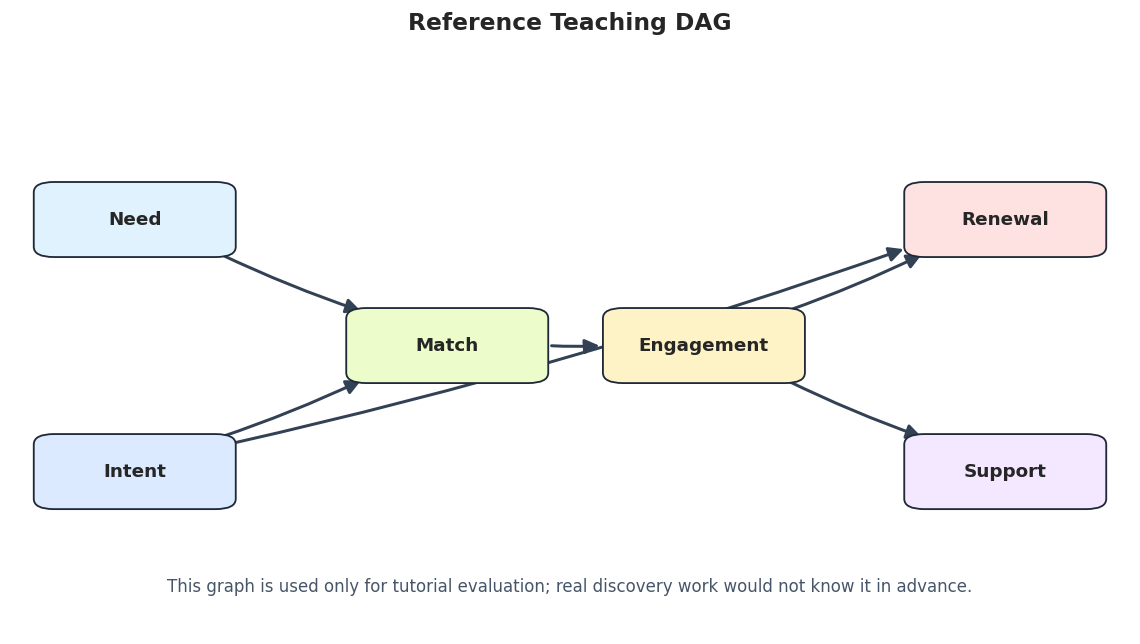

In [5]:
# Draw and save the true synthetic graph in the common tutorial style.
true_edge_table = truth_as_edge_table(true_edges, label="true_graph")
true_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_true_dag.png"
draw_box_graph(
    true_edge_table,
    title="Reference Teaching DAG",
    path=true_graph_path,
    note="This graph is used only for tutorial evaluation; real discovery work would not know it in advance.",
)

The reference graph has a clean forward flow from early context to match quality, engagement, and downstream outcomes. The next section asks how much that temporal logic helps when PC is run with a permissive alpha that otherwise over-connects and misorients the graph.

## Background Knowledge: What It Means And What It Does Not Mean

Background knowledge lets us tell PC that certain directions are impossible or that certain directions are required. In causal-learn, one common way to express this is through **tiers**. A node in a later tier is not allowed to point into a node in an earlier tier. For example, if `renewal` is measured after `intent`, then `renewal -> intent` should be forbidden.

This is useful, but it must be used honestly. Background knowledge should encode timing, design constraints, or strong domain facts. It should not be used to force the graph to match a preferred story. A good report should say exactly which constraints were applied and why.

In [6]:
# Convert the teaching tier table into causal-learn BackgroundKnowledge.
tier_map = dict(zip(variable_roles["variable"], variable_roles["knowledge_tier"]))
background_knowledge, knowledge_nodes = make_tier_background_knowledge(tier_map)

# Build a readable table of pairwise directions forbidden by the tier design.
forbidden_rows = []
for source in VARIABLES:
    for target in VARIABLES:
        if source == target:
            continue
        source_node = knowledge_nodes[source]
        target_node = knowledge_nodes[target]
        if background_knowledge.is_forbidden(source_node, target_node):
            forbidden_rows.append(
                {
                    "forbidden_direction": f"{source} -> {target}",
                    "reason": "later-to-earlier tier" if tier_map[source] > tier_map[target] else "within downstream outcome tier",
                }
            )

forbidden_knowledge = pd.DataFrame(forbidden_rows)
forbidden_knowledge.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_background_knowledge_forbidden_edges.csv", index=False)

display(variable_roles[["variable", "role", "knowledge_tier"]])
display(forbidden_knowledge)

,variable,role,knowledge_tier
0,need,early context,0
1,intent,early context,0
2,match,intermediate,1
3,engagement,intermediate,2
4,renewal,downstream outcome,3
5,support,downstream outcome,3


,forbidden_direction,reason
0,match -> need,later-to-earlier tier
1,match -> intent,later-to-earlier tier
2,engagement -> need,later-to-earlier tier
3,engagement -> intent,later-to-earlier tier
4,engagement -> match,later-to-earlier tier
5,renewal -> need,later-to-earlier tier
6,renewal -> intent,later-to-earlier tier
7,renewal -> match,later-to-earlier tier
8,renewal -> engagement,later-to-earlier tier
9,renewal -> support,within downstream outcome tier


The forbidden-direction table is the audit trail for the prior knowledge. Notice that it does not say every forward edge exists; it only blocks directions that violate the tier ordering. PC still has to decide whether an adjacency is supported by conditional independence evidence.

## PC Without Background Knowledge Under A Permissive Alpha

The previous notebook showed that `alpha` controls how aggressively PC removes edges. A larger alpha can leave too many adjacencies in the graph because more conditional independence tests are treated as evidence against independence. We use `alpha=0.20` here on purpose because it creates a graph where background knowledge has something visible to correct.

In [7]:
# Run PC with a permissive alpha and no background knowledge.
high_alpha_no_prior = pc(
    linear_df[VARIABLES].to_numpy(),
    alpha=0.20,
    indep_test="fisherz",
    stable=True,
    show_progress=False,
    node_names=VARIABLES,
)

high_alpha_no_prior_edges = graph_to_edge_table(high_alpha_no_prior, label="high_alpha_no_prior")
high_alpha_no_prior_metrics = summarize_against_truth(high_alpha_no_prior_edges, true_edges, "high_alpha_no_prior")
high_alpha_no_prior_classified = classify_learned_edges(high_alpha_no_prior_edges, true_edges)

high_alpha_no_prior_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_high_alpha_no_prior_edges.csv", index=False)
high_alpha_no_prior_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_high_alpha_no_prior_metrics.csv", index=False)
high_alpha_no_prior_classified.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_high_alpha_no_prior_edge_classification.csv", index=False)

display(high_alpha_no_prior_edges)
display(high_alpha_no_prior_metrics)
display(high_alpha_no_prior_classified)

,run,source,edge_type,target
0,high_alpha_no_prior,match,-->,need
1,high_alpha_no_prior,renewal,-->,need
2,high_alpha_no_prior,support,-->,need
3,high_alpha_no_prior,intent,---,match
4,high_alpha_no_prior,intent,-->,renewal
5,high_alpha_no_prior,match,---,engagement
6,high_alpha_no_prior,engagement,-->,renewal
7,high_alpha_no_prior,engagement,---,support


,run,learned_edges_total,learned_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies
0,high_alpha_no_prior,8,5,6,2,0.4,0.333333,1,3,0,2


,source,edge_type,target,status
0,match,-->,need,reversed true edge
1,renewal,-->,need,extra adjacency
2,support,-->,need,extra adjacency
3,intent,---,match,true adjacency with uncertain or wrong endpoint
4,intent,-->,renewal,correct directed edge
5,match,---,engagement,true adjacency with uncertain or wrong endpoint
6,engagement,-->,renewal,correct directed edge
7,engagement,---,support,true adjacency with uncertain or wrong endpoint


The no-prior graph is intentionally messy. Some true adjacencies are present but not oriented, some directions are reversed, and extra adjacencies appear. That makes this a useful stress test for the next cell: can reasonable temporal knowledge prevent impossible edge directions without pretending to solve every problem?

## Draw The No-Prior Graph

Tables are precise, but graph structure is easier to scan visually. This plot shows the permissive-alpha PC result before background knowledge is applied. Undirected edges are shown as plain lines with endpoint labels, while directed edges use arrows.

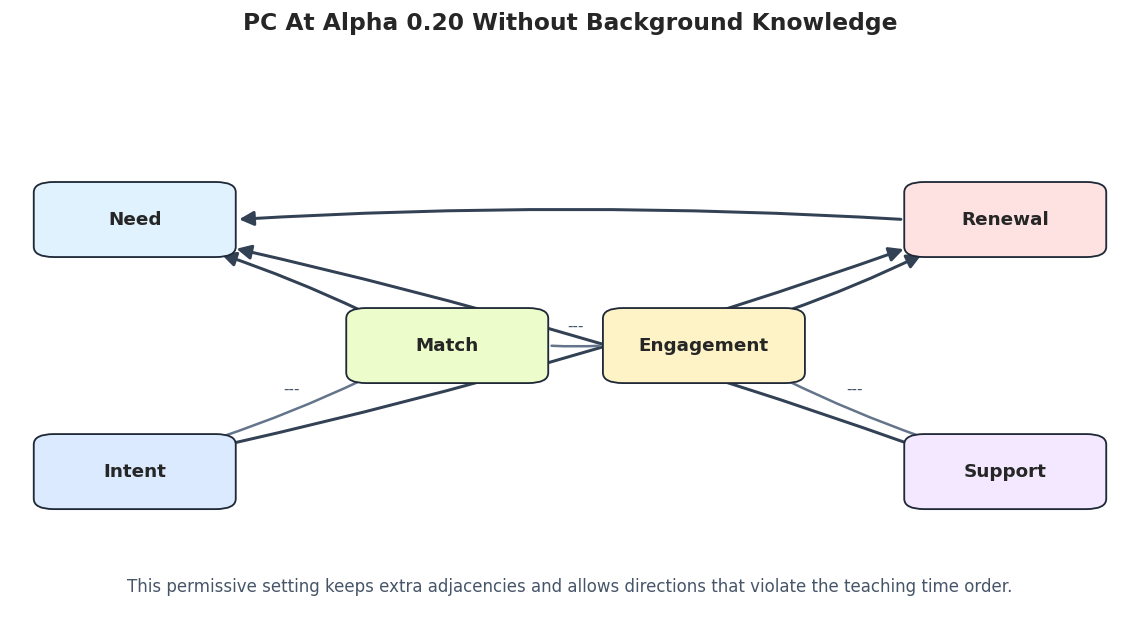

In [8]:
# Save a visual copy of the permissive-alpha graph before adding background knowledge.
no_prior_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_high_alpha_no_prior_graph.png"
draw_box_graph(
    high_alpha_no_prior_edges,
    title="PC At Alpha 0.20 Without Background Knowledge",
    path=no_prior_graph_path,
    note="This permissive setting keeps extra adjacencies and allows directions that violate the teaching time order.",
)

The plot makes the problem concrete: the learned graph is not merely uncertain; it also contains directions that clash with the known ordering of the variables. The next run keeps the same data and alpha but adds tier-based background knowledge.

## PC With Tier-Based Background Knowledge

Now we pass the `BackgroundKnowledge` object into `pc`. This does not change the data or the conditional independence tests. It changes the orientation stage by telling causal-learn which edge directions are disallowed.

A useful mental model is: background knowledge can remove impossible directions, but it cannot prove that a weak or extra adjacency is causal. That distinction is central to responsible causal discovery reporting.

In [9]:
# Run the same permissive PC configuration with tier-based background knowledge.
high_alpha_with_prior = pc(
    linear_df[VARIABLES].to_numpy(),
    alpha=0.20,
    indep_test="fisherz",
    stable=True,
    show_progress=False,
    node_names=VARIABLES,
    background_knowledge=background_knowledge,
)

high_alpha_with_prior_edges = graph_to_edge_table(high_alpha_with_prior, label="high_alpha_with_prior")
high_alpha_with_prior_metrics = summarize_against_truth(high_alpha_with_prior_edges, true_edges, "high_alpha_with_prior")
high_alpha_with_prior_classified = classify_learned_edges(high_alpha_with_prior_edges, true_edges)

high_alpha_with_prior_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_high_alpha_with_prior_edges.csv", index=False)
high_alpha_with_prior_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_high_alpha_with_prior_metrics.csv", index=False)
high_alpha_with_prior_classified.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_high_alpha_with_prior_edge_classification.csv", index=False)

display(high_alpha_with_prior_edges)
display(high_alpha_with_prior_metrics)
display(high_alpha_with_prior_classified)

,run,source,edge_type,target
0,high_alpha_with_prior,need,-->,match
1,high_alpha_with_prior,need,-->,renewal
2,high_alpha_with_prior,need,-->,support
3,high_alpha_with_prior,intent,-->,match
4,high_alpha_with_prior,intent,-->,renewal
5,high_alpha_with_prior,match,-->,engagement
6,high_alpha_with_prior,engagement,-->,renewal
7,high_alpha_with_prior,engagement,-->,support


,run,learned_edges_total,learned_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies
0,high_alpha_with_prior,8,8,6,6,0.75,1.0,0,0,0,2


,source,edge_type,target,status
0,need,-->,match,correct directed edge
1,need,-->,renewal,extra adjacency
2,need,-->,support,extra adjacency
3,intent,-->,match,correct directed edge
4,intent,-->,renewal,correct directed edge
5,match,-->,engagement,correct directed edge
6,engagement,-->,renewal,correct directed edge
7,engagement,-->,support,correct directed edge


The tier constraints remove the backward directions and recover the true orientations on the true adjacencies in this synthetic example. However, the graph can still contain extra forward edges because the prior knowledge only forbids impossible directions; it does not say which forward links must be absent.

## Draw The Prior-Knowledge Graph

The prior-knowledge graph helps separate two effects. First, the edge directions are now consistent with the tier ordering. Second, the extra forward adjacencies remain visible, reminding us that background knowledge is not a substitute for sensitivity analysis or domain review.

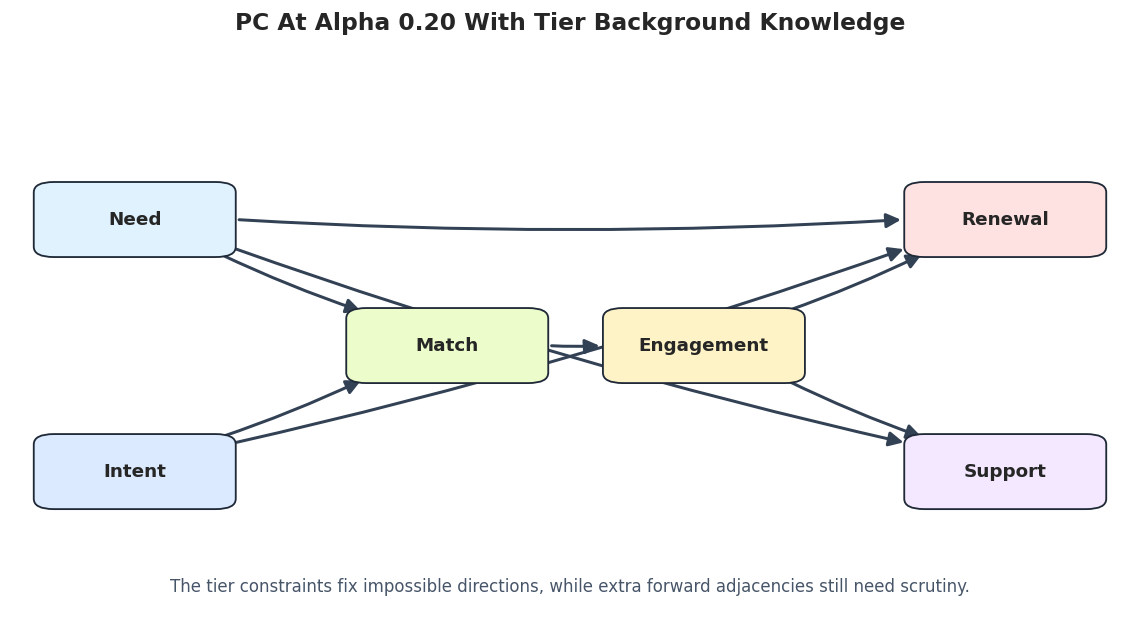

In [10]:
# Save a visual copy of the permissive-alpha graph after adding background knowledge.
with_prior_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_high_alpha_with_prior_graph.png"
draw_box_graph(
    high_alpha_with_prior_edges,
    title="PC At Alpha 0.20 With Tier Background Knowledge",
    path=with_prior_graph_path,
    note="The tier constraints fix impossible directions, while extra forward adjacencies still need scrutiny.",
)

This is the desired teaching outcome: the graph is cleaner but not automatically “true.” The next cell puts the no-prior and with-prior runs side by side so the effect is easier to summarize.

## Compare Background-Knowledge Runs

A compact comparison table makes the effect of background knowledge more transparent than two separate edge lists. We compare directed precision/recall, reversed edges, unresolved true adjacencies, missing true adjacencies, and extra adjacencies.

,run,learned_edges_total,learned_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies
0,high_alpha_no_prior,8,5,6,2,0.40,0.333333,1,3,0,2
1,high_alpha_with_prior,8,8,6,6,0.75,1.000000,0,0,0,2


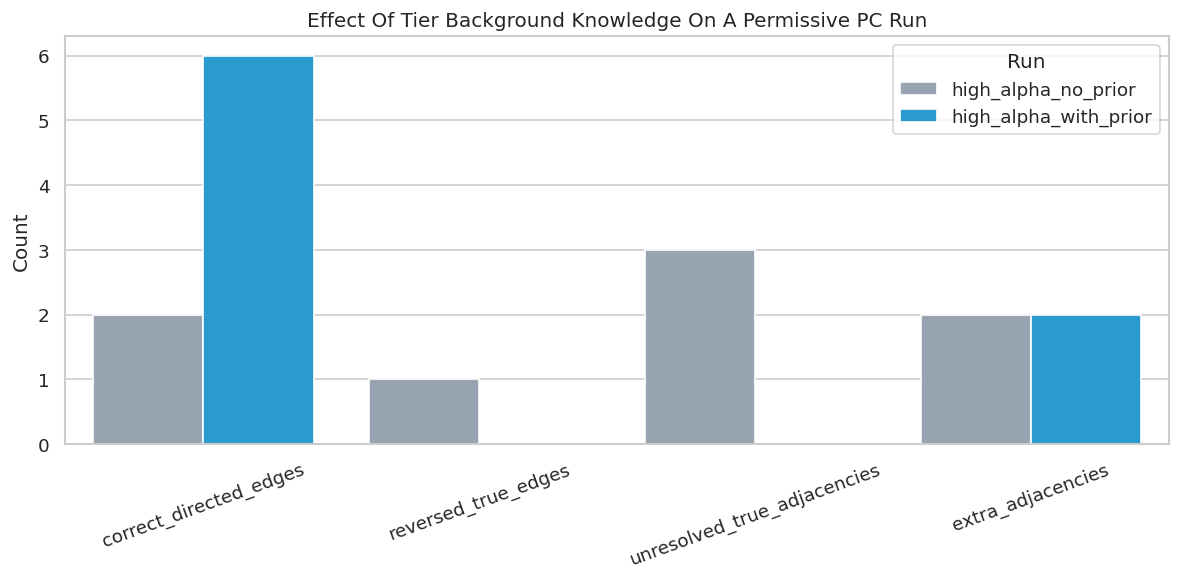

In [11]:
# Compare the two permissive-alpha PC runs using the same custom metrics.
prior_comparison = pd.concat(
    [high_alpha_no_prior_metrics, high_alpha_with_prior_metrics],
    ignore_index=True,
)
prior_comparison.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_prior_knowledge_comparison_metrics.csv", index=False)

display(prior_comparison)

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = prior_comparison.melt(
    id_vars="run",
    value_vars=["correct_directed_edges", "reversed_true_edges", "unresolved_true_adjacencies", "extra_adjacencies"],
    var_name="metric",
    value_name="count",
)
sns.barplot(data=plot_df, x="metric", y="count", hue="run", ax=ax, palette=["#94a3b8", "#0ea5e9"])
ax.set_title("Effect Of Tier Background Knowledge On A Permissive PC Run")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Run", loc="upper right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_prior_knowledge_metric_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

The comparison captures the practical lesson: background knowledge can sharply improve orientation quality when the knowledge is valid, but it does not necessarily reduce extra adjacencies. That is why causal discovery reports should show both the constraints and the remaining uncertainty.

## Missing Data: Create A Transparent Stress Test

The clean continuous dataset has no missing values. To study missing-data behavior, we create a reproducible missingness pattern by randomly masking about one quarter of the cells. This is an intentionally simple missingness mechanism: it is useful for learning the API, not a full missing-data theory.

The key point is operational: ordinary PC cannot accept `NaN` values, complete-case analysis may discard many rows, and missing-value PC can use more of the available data when its assumptions are appropriate.

In [12]:
# Create a reproducible missing-data version of the continuous dataset.
rng = np.random.default_rng(505)
missing_rate_target = 0.25
missing_mask = rng.random(linear_df[VARIABLES].shape) < missing_rate_target
missing_df = linear_df[VARIABLES].mask(missing_mask)
complete_case_df = missing_df.dropna()

missing_summary = pd.DataFrame(
    {
        "variable": VARIABLES,
        "missing_rate": missing_df.isna().mean().reindex(VARIABLES).to_numpy(),
        "non_missing_count": missing_df.notna().sum().reindex(VARIABLES).to_numpy(),
    }
)
missing_overview = pd.DataFrame(
    [
        {"quantity": "original_rows", "value": len(linear_df)},
        {"quantity": "complete_case_rows", "value": len(complete_case_df)},
        {"quantity": "rows_dropped_by_complete_case", "value": len(linear_df) - len(complete_case_df)},
        {"quantity": "overall_missing_cell_rate", "value": missing_df.isna().to_numpy().mean()},
    ]
)

missing_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_missing_value_summary.csv", index=False)
missing_overview.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_missing_value_overview.csv", index=False)
missing_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_linear_gaussian_with_missing_values.csv", index=False)

display(missing_overview)
display(missing_summary)

,quantity,value
0,original_rows,2500.000000
1,complete_case_rows,437.000000
2,rows_dropped_by_complete_case,2063.000000
3,overall_missing_cell_rate,0.250267


,variable,missing_rate,non_missing_count
0,need,0.2504,1874
1,intent,0.2488,1878
2,match,0.2544,1864
3,engagement,0.2428,1893
4,renewal,0.2608,1848
5,support,0.2444,1889


At this missingness level, complete-case analysis keeps only a fraction of the original rows because a row is dropped if any one of the six variables is missing. The next plot shows whether missingness is roughly balanced across variables.

## Plot Missingness By Variable

A missingness plot is a basic data audit. If one variable has much heavier missingness than the others, graph recovery may be affected unevenly because tests involving that variable have less information.

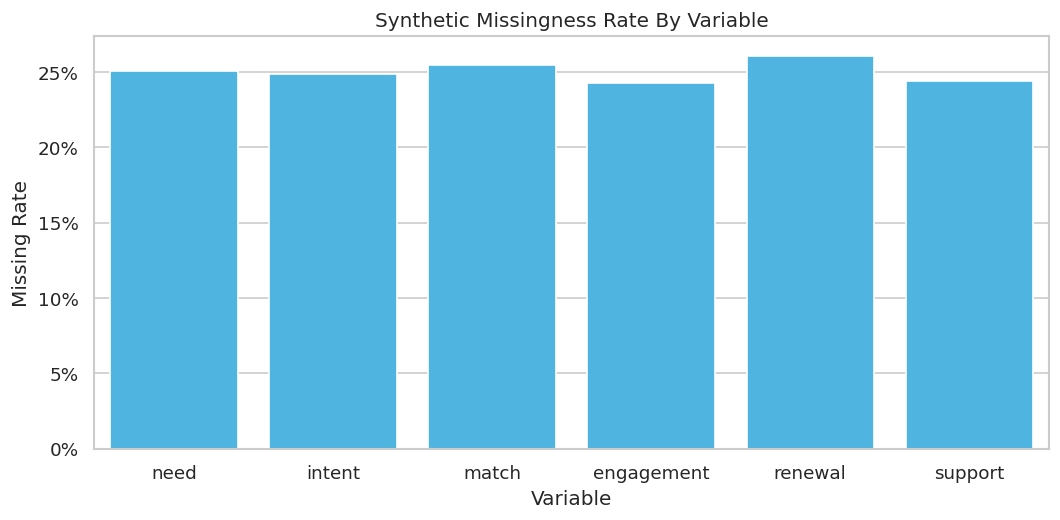

In [13]:
# Plot the per-variable missing rate created for the missing-data stress test.
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=missing_summary, x="variable", y="missing_rate", color="#38bdf8", ax=ax)
ax.set_title("Synthetic Missingness Rate By Variable")
ax.set_xlabel("Variable")
ax.set_ylabel("Missing Rate")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_missingness_by_variable.png", dpi=160, bbox_inches="tight")
plt.show()

The missingness rates are similar across variables because the stress test used a simple random mask. With the missingness audit in place, we can show what happens if ordinary PC is given the incomplete matrix directly.

## Ordinary PC Rejects NaN Values

This cell intentionally tries the wrong thing first: passing a matrix with `NaN` values into ordinary Fisher-Z PC without enabling missing-value PC. The goal is not to produce a graph; it is to make the failure mode explicit.

In [14]:
# Demonstrate that ordinary PC refuses data matrices containing NaN values.
try:
    pc(
        missing_df.to_numpy(),
        alpha=0.05,
        indep_test="fisherz",
        stable=True,
        show_progress=False,
        node_names=VARIABLES,
    )
    nan_check_message = "ordinary PC accepted NaN values"
except Exception as exc:
    nan_check_message = f"{type(exc).__name__}: {exc}"

nan_check = pd.DataFrame([{"run": "ordinary_pc_with_nan_input", "result": nan_check_message}])
nan_check.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_ordinary_pc_nan_check.csv", index=False)
display(nan_check)

,run,result
0,ordinary_pc_with_nan_input,AssertionError: Input data contains NaN. Pleas...


The failure is helpful: it prevents us from accidentally running a method under conditions it does not support. The two practical options shown next are complete-case PC and causal-learn's missing-value PC mode.

## Complete-Case PC

Complete-case analysis drops every row with at least one missing value, then runs ordinary PC on the remaining rows. This is simple and transparent, but it can lose a lot of data and can bias results when the probability of being complete is related to the variables or outcomes.

In [15]:
# Run ordinary Fisher-Z PC after dropping rows that contain any missing value.
complete_case_pc = pc(
    complete_case_df.to_numpy(),
    alpha=0.05,
    indep_test="fisherz",
    stable=True,
    show_progress=False,
    node_names=VARIABLES,
)

complete_case_edges = graph_to_edge_table(complete_case_pc, label="complete_case_pc")
complete_case_metrics = summarize_against_truth(complete_case_edges, true_edges, "complete_case_pc")
complete_case_classified = classify_learned_edges(complete_case_edges, true_edges)

complete_case_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_complete_case_pc_edges.csv", index=False)
complete_case_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_complete_case_pc_metrics.csv", index=False)
complete_case_classified.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_complete_case_pc_edge_classification.csv", index=False)

display(complete_case_edges)
display(complete_case_metrics)
display(complete_case_classified)

,run,source,edge_type,target
0,complete_case_pc,need,-->,match
1,complete_case_pc,intent,-->,match
2,complete_case_pc,intent,-->,engagement
3,complete_case_pc,intent,-->,renewal
4,complete_case_pc,match,-->,engagement
5,complete_case_pc,engagement,-->,renewal
6,complete_case_pc,engagement,-->,support


,run,learned_edges_total,learned_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies
0,complete_case_pc,7,7,6,6,0.857143,1.0,0,0,0,1


,source,edge_type,target,status
0,need,-->,match,correct directed edge
1,intent,-->,match,correct directed edge
2,intent,-->,engagement,extra adjacency
3,intent,-->,renewal,correct directed edge
4,match,-->,engagement,correct directed edge
5,engagement,-->,renewal,correct directed edge
6,engagement,-->,support,correct directed edge


The complete-case run has less data than the original analysis and may add or miss structure depending on the random sample it retains. The next run keeps the incomplete matrix and asks causal-learn to use its missing-value PC correction instead.

## Missing-Value PC

causal-learn exposes missing-value PC through `mvpc=True`. In this mode, the algorithm uses a missing-value correction for Fisher-Z tests rather than requiring a fully observed matrix. This does not make missingness harmless; it simply gives us a method designed for incomplete continuous data under its own assumptions.

In [16]:
# Run missing-value PC on the incomplete matrix.
mvpc_result = pc(
    missing_df.to_numpy(),
    alpha=0.05,
    indep_test="fisherz",
    stable=True,
    show_progress=False,
    node_names=VARIABLES,
    mvpc=True,
    correction_name="MV_Crtn_Fisher_Z",
)

mvpc_edges = graph_to_edge_table(mvpc_result, label="mvpc")
mvpc_metrics = summarize_against_truth(mvpc_edges, true_edges, "mvpc")
mvpc_classified = classify_learned_edges(mvpc_edges, true_edges)

mvpc_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_mvpc_edges.csv", index=False)
mvpc_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_mvpc_metrics.csv", index=False)
mvpc_classified.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_mvpc_edge_classification.csv", index=False)

display(mvpc_edges)
display(mvpc_metrics)
display(mvpc_classified)

,run,source,edge_type,target
0,mvpc,need,-->,match
1,mvpc,intent,-->,match
2,mvpc,intent,-->,renewal
3,mvpc,match,-->,engagement
4,mvpc,engagement,-->,renewal
5,mvpc,engagement,-->,support


,run,learned_edges_total,learned_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies
0,mvpc,6,6,6,6,1.0,1.0,0,0,0,0


,source,edge_type,target,status
0,need,-->,match,correct directed edge
1,intent,-->,match,correct directed edge
2,intent,-->,renewal,correct directed edge
3,match,-->,engagement,correct directed edge
4,engagement,-->,renewal,correct directed edge
5,engagement,-->,support,correct directed edge


The missing-value PC result uses more of the incomplete data matrix than complete-case analysis. In this synthetic run, it recovers the intended structure more cleanly than the complete-case graph, but the responsible claim is narrower: the missing-value method is better aligned with incomplete data than ordinary PC, not universally superior.

## Draw The Missing-Value PC Graph

The graph below visualizes the missing-value PC result. The table above remains the authoritative record, while the figure helps communicate the recovered candidate structure.

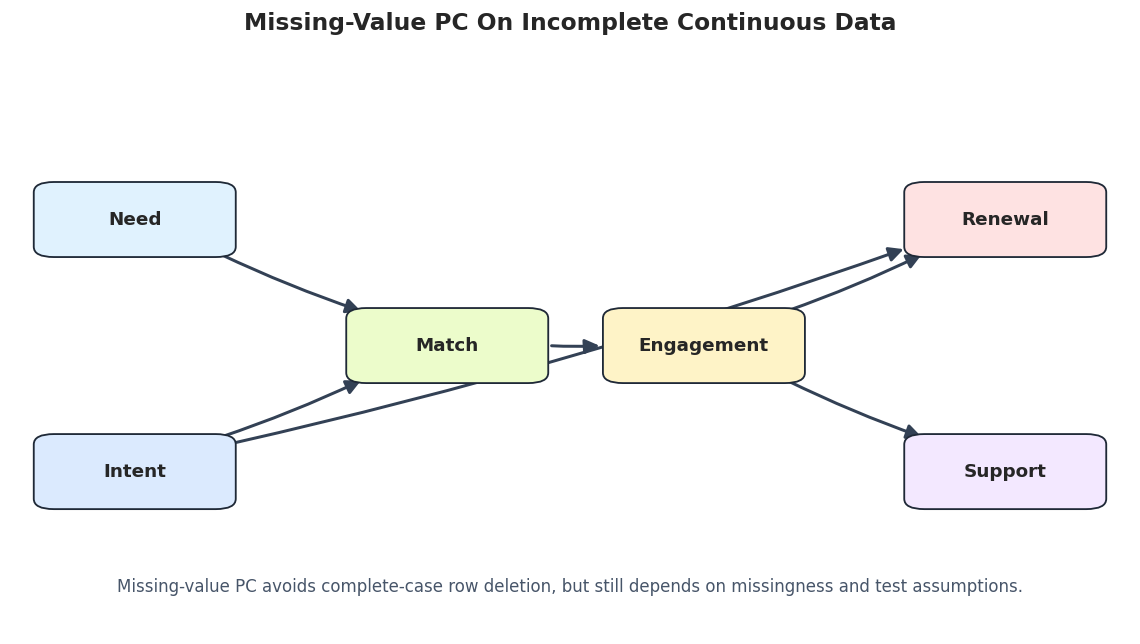

In [17]:
# Save the missing-value PC graph.
mvpc_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_mvpc_graph.png"
draw_box_graph(
    mvpc_edges,
    title="Missing-Value PC On Incomplete Continuous Data",
    path=mvpc_graph_path,
    note="Missing-value PC avoids complete-case row deletion, but still depends on missingness and test assumptions.",
)

The missing-value graph is easy to compare with the reference graph because it uses the same layout. The next cell summarizes complete-case PC and missing-value PC side by side.

## Compare Missing-Data Strategies

This comparison combines the row counts with graph-recovery metrics. A useful missing-data report should show both: a graph may look good, but the analyst should still know how much data was discarded or retained.

,run,learned_edges_total,learned_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies,analysis_rows,contains_missing_values
0,complete_case_pc,7,7,6,6,0.857143,1.0,0,0,0,1,437,False
1,mvpc,6,6,6,6,1.000000,1.0,0,0,0,0,2500,True


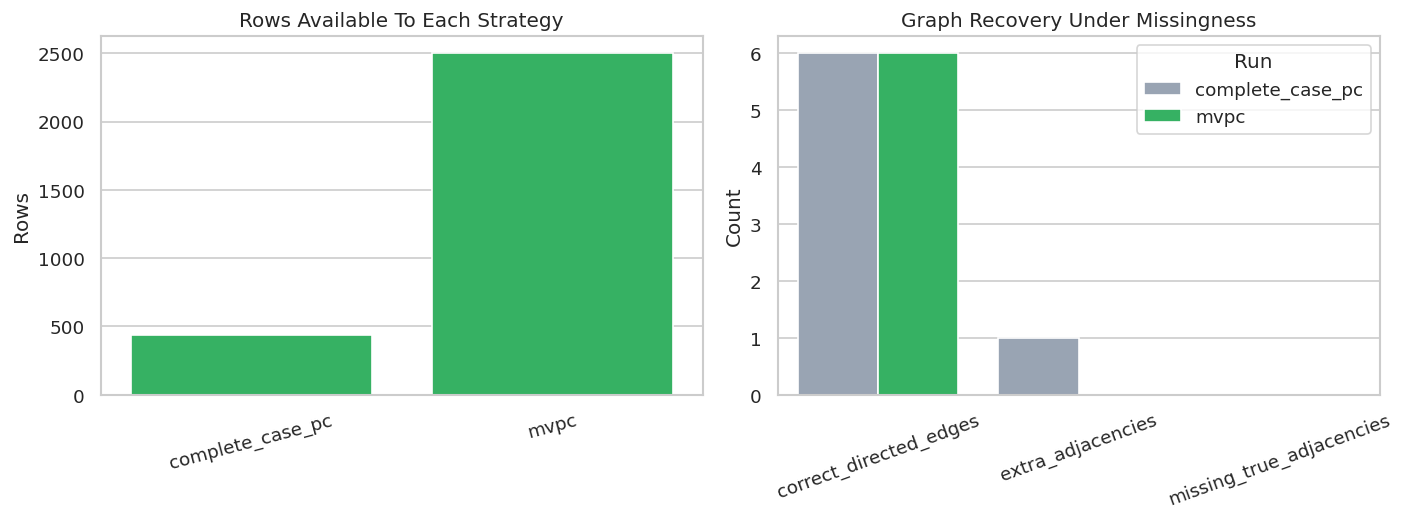

In [18]:
# Compare complete-case PC and missing-value PC with both sample-size and graph metrics.
missing_strategy_metrics = pd.concat([complete_case_metrics, mvpc_metrics], ignore_index=True)
missing_strategy_metrics = missing_strategy_metrics.merge(
    pd.DataFrame(
        [
            {"run": "complete_case_pc", "analysis_rows": len(complete_case_df), "contains_missing_values": False},
            {"run": "mvpc", "analysis_rows": len(missing_df), "contains_missing_values": True},
        ]
    ),
    on="run",
    how="left",
)
missing_strategy_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_missing_strategy_comparison_metrics.csv", index=False)

display(missing_strategy_metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=missing_strategy_metrics, x="run", y="analysis_rows", color="#22c55e", ax=axes[0])
axes[0].set_title("Rows Available To Each Strategy")
axes[0].set_xlabel("")
axes[0].set_ylabel("Rows")
axes[0].tick_params(axis="x", rotation=15)

metric_plot = missing_strategy_metrics.melt(
    id_vars="run",
    value_vars=["correct_directed_edges", "extra_adjacencies", "missing_true_adjacencies"],
    var_name="metric",
    value_name="count",
)
sns.barplot(data=metric_plot, x="metric", y="count", hue="run", ax=axes[1], palette=["#94a3b8", "#22c55e"])
axes[1].set_title("Graph Recovery Under Missingness")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="Run")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_missing_strategy_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

The row-count panel explains why complete-case analysis can become fragile as missingness grows. The graph-metric panel shows that using a method designed for missing values can preserve structure in this controlled example, while still leaving assumptions to document.

## Discrete Data: Why Fisher-Z Is No Longer The Default

Fisher-Z PC assumes continuous variables with partial correlations carrying the conditional independence signal. The discrete teaching dataset contains integer-valued variables, so we switch to discrete conditional independence tests:

- `chisq`: chi-square conditional independence test;
- `gsq`: likelihood-ratio G-square conditional independence test.

These tests are better matched to categorical data, but they still need enough observations in conditioning strata. Sparse categories can make high-dimensional conditioning unreliable.

In [19]:
# Audit the discrete data before choosing discrete conditional independence tests.
discrete_profile_rows = []
for column in VARIABLES:
    counts = discrete_df[column].value_counts().sort_index()
    discrete_profile_rows.append(
        {
            "variable": column,
            "unique_values": int(discrete_df[column].nunique()),
            "min_value": int(discrete_df[column].min()),
            "max_value": int(discrete_df[column].max()),
            "smallest_category_count": int(counts.min()),
            "largest_category_count": int(counts.max()),
        }
    )

discrete_profile = pd.DataFrame(discrete_profile_rows)
discrete_profile.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_discrete_variable_profile.csv", index=False)
display(discrete_profile)

,variable,unique_values,min_value,max_value,smallest_category_count,largest_category_count
0,need,2,0,1,1231,1269
1,intent,2,0,1,1240,1260
2,match,2,0,1,1040,1460
3,engagement,3,0,2,721,1031
4,renewal,2,0,1,1173,1327
5,support,2,0,1,953,1547


The profile confirms that every column is discrete and low-cardinality. That makes chi-square and G-square reasonable teaching choices, though the graph may still be less clean than the continuous baseline because discretization throws away information.

## Plot Discrete Value Frequencies

Before running PC, it helps to inspect category balance. Severe imbalance can make conditional independence tests unstable because many conditioning cells have few observations.

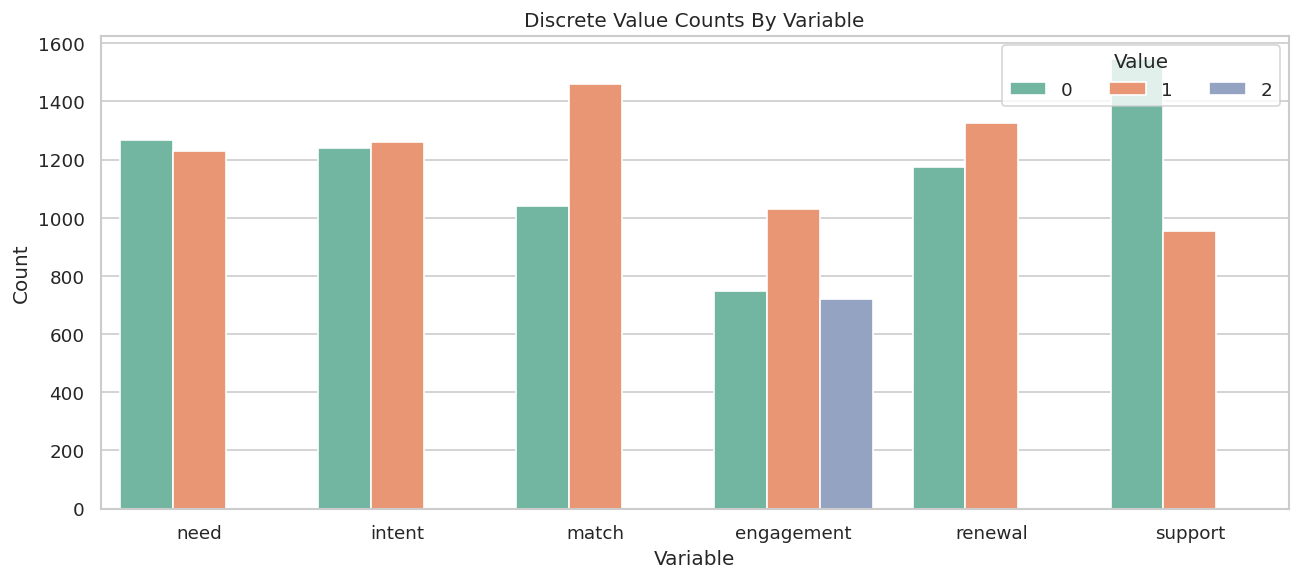

In [20]:
# Plot category counts for each discrete variable.
frequency_rows = []
for column in VARIABLES:
    counts = discrete_df[column].value_counts().sort_index()
    for value, count in counts.items():
        frequency_rows.append({"variable": column, "value": str(value), "count": int(count)})

discrete_frequencies = pd.DataFrame(frequency_rows)
discrete_frequencies.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_discrete_value_frequencies.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=discrete_frequencies, x="variable", y="count", hue="value", ax=ax, palette="Set2")
ax.set_title("Discrete Value Counts By Variable")
ax.set_xlabel("Variable")
ax.set_ylabel("Count")
ax.legend(title="Value", ncol=4, loc="upper right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_discrete_value_frequencies.png", dpi=160, bbox_inches="tight")
plt.show()

The category counts are not perfectly balanced, but the dataset is large enough for a first PC demonstration. The next cells run PC twice, once with chi-square and once with G-square, so we can compare whether the test choice changes the learned structure.

## PC With Chi-Square Conditional Independence Tests

This run uses `indep_test="chisq"`, which is appropriate for categorical variables. The rest of the PC settings are kept close to the baseline: stable PC, `alpha=0.05`, and the same variable order.

In [21]:
# Run PC on discrete data with the chi-square CI test.
chisq_pc = pc(
    discrete_df[VARIABLES].to_numpy(),
    alpha=0.05,
    indep_test="chisq",
    stable=True,
    show_progress=False,
    node_names=VARIABLES,
)

chisq_edges = graph_to_edge_table(chisq_pc, label="discrete_chisq_pc")
chisq_metrics = summarize_against_truth(chisq_edges, discrete_true_edges, "discrete_chisq_pc")
chisq_classified = classify_learned_edges(chisq_edges, discrete_true_edges)

chisq_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_discrete_chisq_pc_edges.csv", index=False)
chisq_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_discrete_chisq_pc_metrics.csv", index=False)
chisq_classified.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_discrete_chisq_pc_edge_classification.csv", index=False)

display(chisq_edges)
display(chisq_metrics)
display(chisq_classified)

,run,source,edge_type,target
0,discrete_chisq_pc,need,-->,match
1,discrete_chisq_pc,need,-->,engagement
2,discrete_chisq_pc,match,-->,intent
3,discrete_chisq_pc,intent,---,renewal
4,discrete_chisq_pc,engagement,-->,match
5,discrete_chisq_pc,renewal,-->,engagement
6,discrete_chisq_pc,engagement,-->,support


,run,learned_edges_total,learned_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies
0,discrete_chisq_pc,7,6,6,2,0.333333,0.333333,3,1,0,1


,source,edge_type,target,status
0,need,-->,match,correct directed edge
1,need,-->,engagement,extra adjacency
2,match,-->,intent,reversed true edge
3,intent,---,renewal,true adjacency with uncertain or wrong endpoint
4,engagement,-->,match,reversed true edge
5,renewal,-->,engagement,reversed true edge
6,engagement,-->,support,correct directed edge


The chi-square run finds a candidate graph, but the edge classification shows that discretization can make orientation and adjacency recovery harder. This is a useful warning: choosing the right CI test is necessary, but it does not undo all information loss from coarsening.

## PC With G-Square Conditional Independence Tests

The G-square test is another common discrete conditional independence test. In many examples it agrees with chi-square, but running both is a simple sensitivity check when the data are discrete.

In [22]:
# Run PC on discrete data with the G-square CI test.
gsq_pc = pc(
    discrete_df[VARIABLES].to_numpy(),
    alpha=0.05,
    indep_test="gsq",
    stable=True,
    show_progress=False,
    node_names=VARIABLES,
)

gsq_edges = graph_to_edge_table(gsq_pc, label="discrete_gsq_pc")
gsq_metrics = summarize_against_truth(gsq_edges, discrete_true_edges, "discrete_gsq_pc")
gsq_classified = classify_learned_edges(gsq_edges, discrete_true_edges)

gsq_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_discrete_gsq_pc_edges.csv", index=False)
gsq_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_discrete_gsq_pc_metrics.csv", index=False)
gsq_classified.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_discrete_gsq_pc_edge_classification.csv", index=False)

display(gsq_edges)
display(gsq_metrics)
display(gsq_classified)

,run,source,edge_type,target
0,discrete_gsq_pc,need,-->,match
1,discrete_gsq_pc,need,-->,engagement
2,discrete_gsq_pc,match,-->,intent
3,discrete_gsq_pc,intent,---,renewal
4,discrete_gsq_pc,engagement,-->,match
5,discrete_gsq_pc,renewal,-->,engagement
6,discrete_gsq_pc,engagement,-->,support


,run,learned_edges_total,learned_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies
0,discrete_gsq_pc,7,6,6,2,0.333333,0.333333,3,1,0,1


,source,edge_type,target,status
0,need,-->,match,correct directed edge
1,need,-->,engagement,extra adjacency
2,match,-->,intent,reversed true edge
3,intent,---,renewal,true adjacency with uncertain or wrong endpoint
4,engagement,-->,match,reversed true edge
5,renewal,-->,engagement,reversed true edge
6,engagement,-->,support,correct directed edge


Here the G-square result can be compared directly with the chi-square result. Agreement increases confidence that the finding is not an artifact of a single test implementation; disagreement would tell us to inspect category sparsity, alpha sensitivity, and possible violations of PC assumptions.

## Draw The Discrete PC Graph

We draw the chi-square graph because it is the first discrete run and has the same qualitative structure as the G-square run in this teaching example. The figure is not meant to hide uncertainty; it is a communication layer on top of the edge and metric tables.

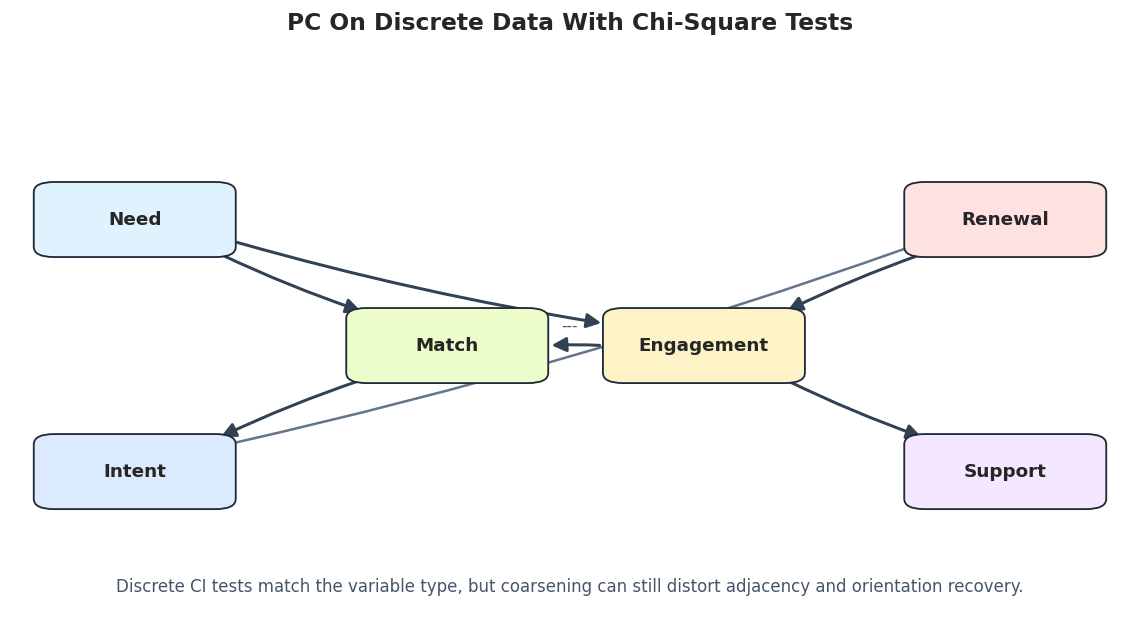

In [23]:
# Save the chi-square discrete PC graph.
discrete_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_discrete_chisq_pc_graph.png"
draw_box_graph(
    chisq_edges,
    title="PC On Discrete Data With Chi-Square Tests",
    path=discrete_graph_path,
    note="Discrete CI tests match the variable type, but coarsening can still distort adjacency and orientation recovery.",
)

The discrete graph is visibly less trustworthy than the clean continuous baseline. That does not make the run useless; it tells us that a discrete-data discovery report should spend more time on sensitivity checks and less time claiming definitive directions.

## Compare Discrete Test Choices

The next table and plot compare chi-square and G-square PC. This is a small example of algorithmic sensitivity analysis: keep the data and PC settings fixed while changing one modeling choice.

,run,learned_edges_total,learned_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies
0,discrete_chisq_pc,7,6,6,2,0.333333,0.333333,3,1,0,1
1,discrete_gsq_pc,7,6,6,2,0.333333,0.333333,3,1,0,1


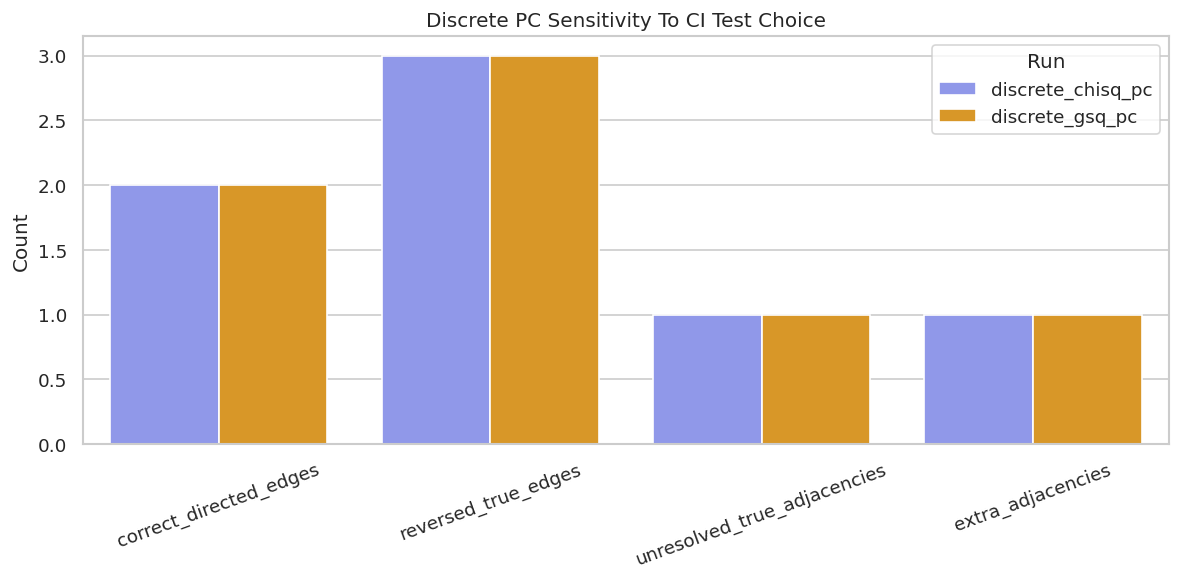

In [24]:
# Compare chi-square and G-square graph recovery metrics.
discrete_test_comparison = pd.concat([chisq_metrics, gsq_metrics], ignore_index=True)
discrete_test_comparison.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_discrete_test_comparison_metrics.csv", index=False)

display(discrete_test_comparison)

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = discrete_test_comparison.melt(
    id_vars="run",
    value_vars=["correct_directed_edges", "reversed_true_edges", "unresolved_true_adjacencies", "extra_adjacencies"],
    var_name="metric",
    value_name="count",
)
sns.barplot(data=plot_df, x="metric", y="count", hue="run", ax=ax, palette=["#818cf8", "#f59e0b"])
ax.set_title("Discrete PC Sensitivity To CI Test Choice")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Run")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_discrete_test_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

The comparison shows whether the two discrete tests tell the same story. When they agree, the next concern is not test choice but whether the data representation, sample size, and causal assumptions are strong enough for the graph to be useful.

## Combined Scenario Summary

We have now run three extensions of the basic PC workflow: background knowledge, missing values, and discrete tests. A combined summary helps connect them into one decision table rather than a collection of separate experiments.

In [25]:
# Combine the main scenario metrics into one table for reporting.
scenario_summary = pd.concat(
    [
        high_alpha_no_prior_metrics,
        high_alpha_with_prior_metrics,
        complete_case_metrics,
        mvpc_metrics,
        chisq_metrics,
        gsq_metrics,
    ],
    ignore_index=True,
)
scenario_summary["scenario"] = [
    "permissive alpha without prior knowledge",
    "permissive alpha with tier prior knowledge",
    "missing data with complete-case PC",
    "missing data with missing-value PC",
    "discrete data with chi-square PC",
    "discrete data with G-square PC",
]
scenario_summary = scenario_summary[["scenario"] + [col for col in scenario_summary.columns if col != "scenario"]]
scenario_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_scenario_summary_metrics.csv", index=False)
display(scenario_summary)

,scenario,run,learned_edges_total,learned_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies
0,permissive alpha without prior knowledge,high_alpha_no_prior,8,5,6,2,0.400000,0.333333,1,3,0,2
1,permissive alpha with tier prior knowledge,high_alpha_with_prior,8,8,6,6,0.750000,1.000000,0,0,0,2
2,missing data with complete-case PC,complete_case_pc,7,7,6,6,0.857143,1.000000,0,0,0,1
3,missing data with missing-value PC,mvpc,6,6,6,6,1.000000,1.000000,0,0,0,0
4,discrete data with chi-square PC,discrete_chisq_pc,7,6,6,2,0.333333,0.333333,3,1,0,1
5,discrete data with G-square PC,discrete_gsq_pc,7,6,6,2,0.333333,0.333333,3,1,0,1


This table is the main “what did we learn?” artifact. It shows that each extension solves a different problem: prior knowledge affects orientation constraints, missing-value PC affects incomplete continuous data, and discrete tests affect the appropriateness of the CI test.

## Reporting Checklist

The final checklist converts the notebook into reusable reporting guidance. If a causal discovery analysis uses any of these extensions, the report should make the relevant assumptions and choices explicit.

In [26]:
# Save a reporting checklist that can be reused in future PC analyses.
reporting_checklist = pd.DataFrame(
    [
        {
            "topic": "background knowledge",
            "reporting_question": "Which directions were forbidden or required, and what external reason justifies each constraint?",
            "why_it_matters": "Invalid priors can force a graph to tell a misleading story.",
        },
        {
            "topic": "alpha choice",
            "reporting_question": "How sensitive is the graph to the conditional independence alpha threshold?",
            "why_it_matters": "A single alpha can hide edge instability.",
        },
        {
            "topic": "missing data",
            "reporting_question": "How many rows or cells are missing, and was complete-case analysis or missing-value PC used?",
            "why_it_matters": "Missingness can change both sample size and dependence structure.",
        },
        {
            "topic": "discrete tests",
            "reporting_question": "Were discrete variables tested with chi-square, G-square, or another categorical CI test?",
            "why_it_matters": "Continuous CI tests are not the default choice for categorical variables.",
        },
        {
            "topic": "graph claims",
            "reporting_question": "Which edges are stable candidate structure, and which are uncertain or assumption-dependent?",
            "why_it_matters": "Discovery graphs should not be oversold as confirmed causal truth.",
        },
    ]
)
reporting_checklist.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pc_extensions_reporting_checklist.csv", index=False)
display(reporting_checklist)

,topic,reporting_question,why_it_matters
0,background knowledge,"Which directions were forbidden or required, a...",Invalid priors can force a graph to tell a mis...
1,alpha choice,How sensitive is the graph to the conditional ...,A single alpha can hide edge instability.
2,missing data,"How many rows or cells are missing, and was co...",Missingness can change both sample size and de...
3,discrete tests,Were discrete variables tested with chi-square...,Continuous CI tests are not the default choice...
4,graph claims,"Which edges are stable candidate structure, an...",Discovery graphs should not be oversold as con...


The checklist is intentionally practical. It turns the notebook from a one-off demonstration into a template for future PC analyses where the data are not clean, continuous, and assumption-perfect.

## Artifact Manifest

The last code cell lists the key files generated by this notebook. This makes it easy to find the saved tables and figures without scrolling through the whole notebook.

In [27]:
# Inventory the artifacts created by this notebook.
artifact_rows = []
for folder, artifact_type in [(TABLE_DIR, "table"), (FIGURE_DIR, "figure"), (DATASET_DIR, "dataset")]:
    for artifact_path in sorted(folder.glob(f"{NOTEBOOK_PREFIX}_*")):
        artifact_rows.append(
            {
                "artifact_type": artifact_type,
                "file_name": artifact_path.name,
                "relative_path": str(artifact_path.relative_to(NOTEBOOK_DIR)),
                "size_kb": round(artifact_path.stat().st_size / 1024, 1),
            }
        )

artifact_manifest = pd.DataFrame(artifact_rows)
artifact_manifest.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_artifact_manifest.csv", index=False)
display(artifact_manifest)

,artifact_type,file_name,relative_path,size_kb
0,table,05_artifact_manifest.csv,outputs/tables/05_artifact_manifest.csv,4.0
1,table,05_background_knowledge_forbidden_edges.csv,outputs/tables/05_background_knowledge_forbidd...,0.6
2,table,05_complete_case_pc_edge_classification.csv,outputs/tables/05_complete_case_pc_edge_classi...,0.3
3,table,05_complete_case_pc_edges.csv,outputs/tables/05_complete_case_pc_edges.csv,0.3
4,table,05_complete_case_pc_metrics.csv,outputs/tables/05_complete_case_pc_metrics.csv,0.3
5,table,05_discrete_chisq_pc_edge_classification.csv,outputs/tables/05_discrete_chisq_pc_edge_class...,0.3
6,table,05_discrete_chisq_pc_edges.csv,outputs/tables/05_discrete_chisq_pc_edges.csv,0.3
7,table,05_discrete_chisq_pc_metrics.csv,outputs/tables/05_discrete_chisq_pc_metrics.csv,0.3
8,table,05_discrete_gsq_pc_edge_classification.csv,outputs/tables/05_discrete_gsq_pc_edge_classif...,0.3
9,table,05_discrete_gsq_pc_edges.csv,outputs/tables/05_discrete_gsq_pc_edges.csv,0.3


The notebook now has a full audit trail: input data summaries, knowledge constraints, learned edge lists, graph-recovery metrics, figures, and a checklist. The next tutorial notebook can build on this by moving from PC to FCI, where hidden common causes are represented explicitly through PAG endpoints.